In [1]:
print("hello")

hello


Retrieving forecasts and DWD actuals for Berlin (2026-08-29 to 2026-09-05)...

--- MODEL PERFORMANCE VS. DWD OBSERVATIONS ---
             Variable      Model  RMSE   MAE   Bias  Pearson_r  N_Samples
  Temperature 2m (°C)  GraphCast   NaN   NaN    NaN        NaN        NaN
  Temperature 2m (°C) ECMWF AIFS   NaN   NaN    NaN        NaN        NaN
  Temperature 2m (°C)   DWD ICON 1.406 1.039  0.824      0.948      168.0
Wind Speed 10m (km/h)  GraphCast   NaN   NaN    NaN        NaN        NaN
Wind Speed 10m (km/h) ECMWF AIFS   NaN   NaN    NaN        NaN        NaN
Wind Speed 10m (km/h)   DWD ICON 8.725 8.130 -8.105      0.837      168.0


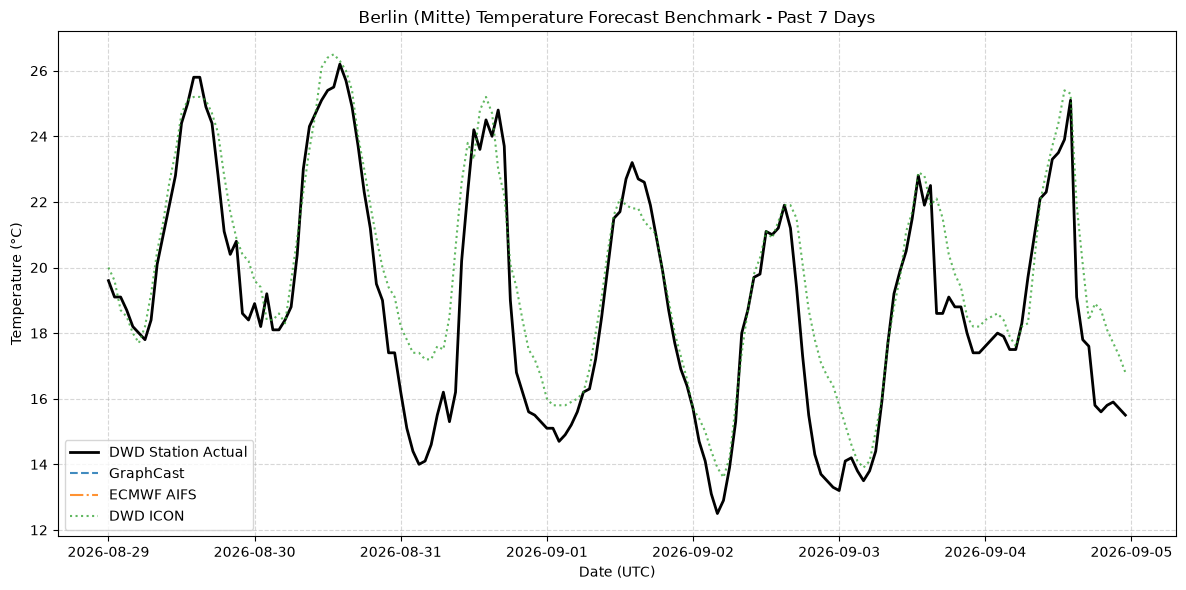

In [2]:
from datetime import datetime, timedelta, timezone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# Coordinates for Berlin (Mitte / Alexanderplatz)
LAT = 52.5200
LON = 13.4050
PAST_DAYS = 7  # Evaluation window in days


def get_forecast_models(lat: float, lon: float, past_days: int) -> pd.DataFrame:
    """Fetch archived hourly model runs (AI models + NWP baseline) from Open-Meteo."""
    url = "https://api.open-meteo.com/v1/forecast"
    models = ["gfs_graphcast025", "ecmwf_aifs025", "dwd_icon"]

    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ["temperature_2m", "wind_speed_10m"],
        "models": ",".join(models),
        "past_days": past_days,
        "forecast_days": 0,  # Only evaluate past completed hours
        "timezone": "UTC",
        "wind_speed_unit": "kmh",
    }

    resp = requests.get(url, params=params, timeout=15)
    resp.raise_for_status()
    data = resp.json()["hourly"]

    df = pd.DataFrame(data)
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df.set_index("time")


def get_dwd_station_actuals(
    lat: float, lon: float, start_dt: datetime, end_dt: datetime
) -> pd.DataFrame:
    """Fetch actual DWD weather station observations via the Bright Sky API."""
    url = "https://api.brightsky.dev/weather"
    params = {
        "lat": lat,
        "lon": lon,
        "date": start_dt.strftime("%Y-%m-%d"),
        "last_date": end_dt.strftime("%Y-%m-%d"),
        "tz": "UTC",
    }

    resp = requests.get(url, params=params, timeout=15)
    resp.raise_for_status()
    records = resp.json()["weather"]

    df = pd.DataFrame(records)[["timestamp", "temperature", "wind_speed"]]
    df["time"] = pd.to_datetime(df["timestamp"], utc=True)
    df = df.rename(
        columns={
            "temperature": "actual_temperature_2m",
            "wind_speed": "actual_wind_speed_10m",
        }
    )
    return df.drop(columns=["timestamp"]).set_index("time")


def calculate_metrics(y_true: pd.Series, y_pred: pd.Series) -> dict:
    """Compute verification statistics between observed and predicted time series."""
    valid_mask = ~y_true.isna() & ~y_pred.isna()
    yt = y_true[valid_mask].to_numpy()
    yp = y_pred[valid_mask].to_numpy()

    if len(yt) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "Bias": np.nan, "Pearson_r": np.nan}

    error = yp - yt
    rmse = np.sqrt(np.mean(error**2))
    mae = np.mean(np.abs(error))
    bias = np.mean(error)  # Positive = over-forecast, Negative = under-forecast
    r = np.corrcoef(yt, yp)[0, 1]

    return {
        "RMSE": round(float(rmse), 3),
        "MAE": round(float(mae), 3),
        "Bias": round(float(bias), 3),
        "Pearson_r": round(float(r), 3),
        "N_Samples": int(len(yt)),
    }


def main():
    end_date = datetime.now(timezone.utc)
    start_date = end_date - timedelta(days=PAST_DAYS)

    print(
        f"Retrieving forecasts and DWD actuals for Berlin ({start_date.date()} to {end_date.date()})..."
    )
    df_fc = get_forecast_models(LAT, LON, PAST_DAYS)
    df_act = get_dwd_station_actuals(LAT, LON, start_date, end_date)

    # Inner join on UTC timestamps
    df_eval = df_fc.join(df_act, how="inner").sort_index()

    variables = {
        "Temperature 2m (°C)": {
            "actual": "actual_temperature_2m",
            "models": {
                "GraphCast": "temperature_2m_gfs_graphcast025",
                "ECMWF AIFS": "temperature_2m_ecmwf_aifs025",
                "DWD ICON": "temperature_2m_dwd_icon",
            },
        },
        "Wind Speed 10m (km/h)": {
            "actual": "actual_wind_speed_10m",
            "models": {
                "GraphCast": "wind_speed_10m_gfs_graphcast025",
                "ECMWF AIFS": "wind_speed_10m_ecmwf_aifs025",
                "DWD ICON": "wind_speed_10m_dwd_icon",
            },
        },
    }

    # Generate benchmark summary table
    results = []
    for var_name, config in variables.items():
        actual_col = config["actual"]
        for model_label, model_col in config["models"].items():
            if model_col in df_eval.columns:
                metrics = calculate_metrics(df_eval[actual_col], df_eval[model_col])
                metrics["Variable"] = var_name
                metrics["Model"] = model_label
                results.append(metrics)

    summary_df = pd.DataFrame(results)[
        ["Variable", "Model", "RMSE", "MAE", "Bias", "Pearson_r", "N_Samples"]
    ]
    print("\n--- MODEL PERFORMANCE VS. DWD OBSERVATIONS ---")
    print(summary_df.to_string(index=False))

    # Plot 2m Temperature Actual vs Predictions
    plt.figure(figsize=(12, 6))
    plt.plot(
        df_eval.index,
        df_eval["actual_temperature_2m"],
        label="DWD Station Actual",
        color="black",
        linewidth=2,
    )
    if "temperature_2m_gfs_graphcast025" in df_eval.columns:
        plt.plot(
            df_eval.index,
            df_eval["temperature_2m_gfs_graphcast025"],
            label="GraphCast",
            linestyle="--",
            alpha=0.85,
        )
    if "temperature_2m_ecmwf_aifs025" in df_eval.columns:
        plt.plot(
            df_eval.index,
            df_eval["temperature_2m_ecmwf_aifs025"],
            label="ECMWF AIFS",
            linestyle="-.",
            alpha=0.85,
        )
    if "temperature_2m_dwd_icon" in df_eval.columns:
        plt.plot(
            df_eval.index,
            df_eval["temperature_2m_dwd_icon"],
            label="DWD ICON",
            linestyle=":",
            alpha=0.75,
        )

    plt.title(
        f"Berlin (Mitte) Temperature Forecast Benchmark - Past {PAST_DAYS} Days"
    )
    plt.ylabel("Temperature (°C)")
    plt.xlabel("Date (UTC)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()